# Walkthrough: tracing and steering a circuit in FLUX.1[schnell]

End-to-end demo of `transcoder_circuits`, following the method of the paper: build a **Local Replacement Model**, extract an **attribution graph** for a target feature, prune it, inspect the features, and run a **circuit-guided intervention**.

We trace the image-stream red feature $f^{(img,10)}_{red}$ on _"a red car on a green field"_, then run a **circuit-guided** intervention on its upstream **source** features (the text-stream _red_ features feeding it in the graph) - not on the target feature itself, which would be ordinary single-feature steering.

In [1]:
import os

os.environ.setdefault("TRANSCODERS_DIR", "/path/to/transcoders")

from transcoder_circuits.replacement_model import LRMConfig
from transcoder_circuits.circuit_analysis import LRMPipeline

cfg = LRMConfig(target_layers=tuple(range(16)))
pipeline = LRMPipeline(cfg)
pipeline.initialize()
pipeline.load_transcoders()
pipe, transcoders = pipeline.pipe, pipeline.transcoders

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/219 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

## 1. Trace the circuit for the target feature

`run_experiment` captures the forward trace, builds the per-position attribution graph, aggregates positions, prunes graph, validates the conservation invariant + perturbation faithfulness, and writes a JSON graph to disk.

In [2]:
target = {
    "layer": 10,
    "stream": "img",
    "feat_idx": 40684,
    "prompt": "a red car on a green field",
    "seed": 0,
    "step": 0,
}
df = pipeline.run_experiment([target], output_dir="attribution_results")
df

  0%|          | 0/4 [00:00<?, ?it/s]

[1/1] L10 img f40684  950s  pruned 397 nodes / 23014 edges  rel_err 9.93%  spearman 0.696
1 targets processed -> attribution_results/experiment_summary.csv


,target_num,prompt,step,seed,layer,stream,feat_idx,position,preactivation,raw_attribution_expected,...,pruned_attribution_expected,pruned_attribution_actual,pruned_attribution_rel_err,pruned_num_nodes,pruned_num_edges,elapsed_seconds,spearman_r,pearson_r,n_nonzero_pairs,graph_path
0,1,a red car on a green field,0,0,10,img,40684,268,54.192917,62.692501,...,62.692501,56.466475,0.099311,397,23014,950.449309,0.695766,0.70003,214,attribution_results/circuit_f40684_step0_seed0...


## 2. Visualize the attribution graph

Render the saved graph as an interactive HTML graph.

In [3]:
import glob
from transcoder_circuits import circuit_visualization as cv

graph_path = sorted(glob.glob("attribution_results/*.json"))[-1]
G = cv.load_graph(graph_path)
cv.print_graph_stats(G, 0)
cv.build_interactive_graph(
    G, tooltip_cache={}, idx=0, top_edges=1000, output_file="circuit_graph.html"
)


Graph [0]: L10 img f40684  | a red car on a green field
  step=0  seed=0  rel_err=9.93%
  Nodes: 73 feat-img, 302 feat-txt, 20 error, 2 input  (397 total)
  Edges: 23014 total, 20174 feat, 3555 cross-modal (17.6%)
  Direct attribution to target:
    feat-img: +13.3297 (23.6%)  feat-txt: +21.8131 (38.6%)  error: +13.2019 (23.4%)  input: +8.1218 (14.4%)
Graph[0]: 397 nodes, 1000/23014 edges -> circuit_graph.html


'circuit_graph.html'

In [4]:
# Optional: enrich each feature node's tooltip with its top corpus activations
# (image overlays / token highlights) shown on hover, and pinned on click - the
# full dashboard view. This needs a completed corpus scan from
# feature_dashboards.run_pipeline, which is a heavy GPU pass over ~100k prompts.

# from transcoder_circuits import feature_dashboards as fd
# pipe, prompts, scan, state = ...        # from fd.run_pipeline(cfg) on your GPU
# tips = fd.build_feature_tooltips(G, pipe, prompts, scan, state)
# cv.build_interactive_graph(G, tooltip_cache=tips, idx=0, output_file="circuit_graph.html")

## 3. Circuit-guided intervention

This is what separates circuit tracing from plain steering: instead of acting on the target feature, we suppress its upstream **source** features read off the graph - the text-stream _red_ features feeding $f^{(img,10)}_{red}$. The car loses its red colour while the rest of the scene is preserved. `run_experiment` saves per-seed images and a labelled comparison grid, and displays it inline.

suppress_red_sources: 3 seeds | 'a red car on a green field'
    seed 0 (1/3)


  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

    seed 1 (2/3)


  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

    seed 2 (3/3)


  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

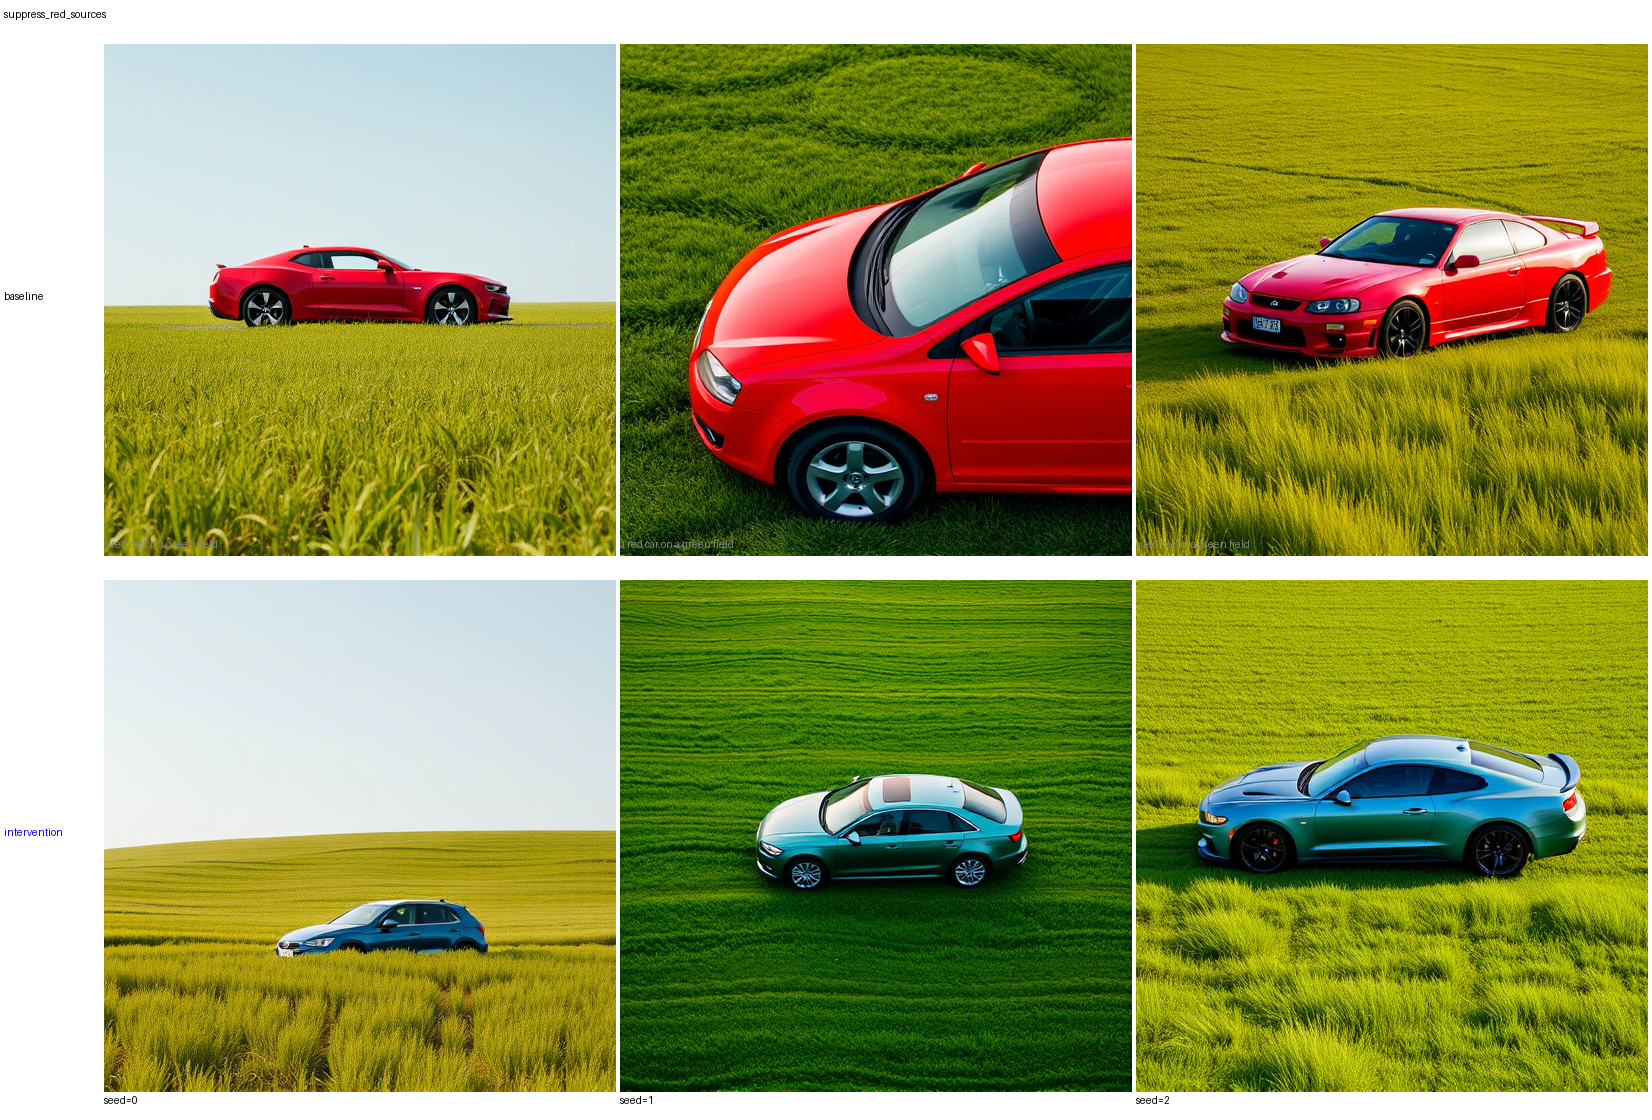

[{'seed': 0,
  'prompt': 'a red car on a green field',
  'config_name': 'suppress_red_sources',
  'baseline': <PIL.Image.Image image mode=RGB size=512x512>,
  'intervention': <PIL.Image.Image image mode=RGB size=512x512>},
 {'seed': 1,
  'prompt': 'a red car on a green field',
  'config_name': 'suppress_red_sources',
  'baseline': <PIL.Image.Image image mode=RGB size=512x512>,
  'intervention': <PIL.Image.Image image mode=RGB size=512x512>},
 {'seed': 2,
  'prompt': 'a red car on a green field',
  'config_name': 'suppress_red_sources',
  'baseline': <PIL.Image.Image image mode=RGB size=512x512>,
  'intervention': <PIL.Image.Image image mode=RGB size=512x512>}]

In [5]:
from transcoder_circuits.interventions import (
    InterventionRunner,
    InterventionConfig,
    FeatureIntervention,
)

RED_SOURCES = [(0, "txt", 26463), (1, "txt", 5559), (3, "txt", 8073)]

runner = InterventionRunner(pipe, transcoders)
suppress_red = InterventionConfig(
    name="suppress_red_sources",
    prompt="a red car on a green field",
    seeds=[0, 1, 2],
    interventions=[
        FeatureIntervention(layer=l, stream=s, feat_idx=i, mode="amplify", scale=-15.0)
        for (l, s, i) in RED_SOURCES
    ],
)
runner.run_experiment([suppress_red], output_dir="interventions_out")